In [ ]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/processeddatawebmining/WebMiningData/y_train.npy
/kaggle/input/processeddatawebmining/WebMiningData/y_test.npy
/kaggle/input/processeddatawebmining/WebMiningData/item_graph.gpickle
/kaggle/input/processeddatawebmining/WebMiningData/X_test.npy
/kaggle/input/processeddatawebmining/WebMiningData/filtered_clicks.csv
/kaggle/input/processeddatawebmining/WebMiningData/X_train.npy


In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import networkx as nx
import os
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
# 0. CONFIGURATION AND DATA LOADING SETUP
# Hyperparameters 
SEED = 42
MAX_TRAIN = 2_000_000  
MAX_TEST = 200_000
EMBEDDING_DIM = 256 
GRAPH_EMBEDDING_DIM = 128
HIDDEN_SIZE = EMBEDDING_DIM + GRAPH_EMBEDDING_DIM 
K_RECS = 20         
BATCH_SIZE = 512
EPOCHS = 15     
GCN_EPOCHS = 100 
GCN_HIDDEN_CHANNELS = 128
GCN_LEARNING_RATE = 0.005
OPTIMIZER_LEARNING_RATE = 0.001

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
rng = np.random.default_rng(SEED)

DATA_DIR = "/kaggle/input/processeddatawebmining/WebMiningData"
OUT_DIR  = "/kaggle/working"
GRAPH_EMBEDDING_FILE = "gesrec_graph_embeddings.pt"
GRAPH_EMBEDDINGS_PATH = os.path.join(OUT_DIR, GRAPH_EMBEDDING_FILE)
os.makedirs(OUT_DIR, exist_ok=True)

X_train_full = np.load(os.path.join(DATA_DIR, "X_train.npy"), allow_pickle=True)
y_train_full = np.load(os.path.join(DATA_DIR, "y_train.npy"), allow_pickle=True)
X_test_full = np.load(os.path.join(DATA_DIR, "X_test.npy"), allow_pickle=True)
y_test_full = np.load(os.path.join(DATA_DIR, "y_test.npy"), allow_pickle=True)
"""
train_idx = rng.choice(len(X_train_full), min(MAX_TRAIN, len(X_train_full)), replace=False)
test_idx = rng.choice(len(X_test_full), min(MAX_TEST, len(X_test_full)), replace=False)

X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]
X_test, y_test = X_test_full[test_idx], y_test_full[test_idx]
"""
X_train, y_train = X_train_full, y_train_full
X_test, y_test = X_test_full, y_test_full



In [ ]:
all_items = set()
for seq in np.concatenate((X_train, X_test)):
    all_items.update(seq)
all_items.update(y_train)
all_items.update(y_test)
unique_items = sorted(list(all_items - {0})) 
ITEM_COUNT_ACTUAL = len(unique_items) 
print(f"Actual Number of Unique Items: {ITEM_COUNT_ACTUAL}")

# 2. Create the mapping
id_to_index = {item_id: index + 1 for index, item_id in enumerate(unique_items)}
id_to_index[0] = 0

ITEM_COUNT = ITEM_COUNT_ACTUAL 

def map_data_to_indices(data, mapper):
    new_data = []
    for seq in data:
        new_seq = np.array([mapper.get(item, 0) for item in seq], dtype=np.int64)
        new_data.append(new_seq)
    return np.array(new_data, dtype=object)

# Apply the mapping
X_train_mapped = map_data_to_indices(X_train, id_to_index)
y_train_mapped = np.array([id_to_index.get(item, 0) for item in y_train], dtype=np.int64)
X_test_mapped = map_data_to_indices(X_test, id_to_index)
y_test_mapped = np.array([id_to_index.get(item, 0) for item in y_test], dtype=np.int64)

Actual Number of Unique Items: 27163


In [ ]:
# 1. GRAPH CONSTRUCTION AND GCN PRE-TRAINING

# Build the Co-occurrence Graph
def build_cooccurrence_graph(sessions):
    """Builds a directed Item-Item Co-occurrence Graph."""
    G = nx.DiGraph()
    for session in tqdm(sessions, desc="Building Graph"):
        for i in range(len(session) - 1):
            u, v = int(session[i]), int(session[i+1])
            if u == 0 or v == 0: continue
            if G.has_edge(u, v):
                G[u][v]['weight'] += 1
            else:
                G.add_edge(u, v, weight=1)
    return G

# Prepare PyG Data
def prepare_pyg_data(G, graph_emb_dim):
    """Converts NetworkX graph to PyG Data object and initializes node features."""
    
    # Map item IDs to contiguous node indices for GCN
    sorted_nodes = sorted(list(G.nodes()))
    node_map = {item_id: i for i, item_id in enumerate(sorted_nodes)}
    
    edge_index = []
    
    for u, v in G.edges():
        edge_index.append([node_map[u], node_map[v]])

    edge_index = torch.tensor(edge_index).t().contiguous()
    
    num_nodes = G.number_of_nodes()
    # Initial features (x) for each item node
    x = torch.randn(num_nodes, graph_emb_dim) 
    
    pyg_data = Data(x=x, edge_index=edge_index)
    
    return pyg_data, node_map, sorted_nodes



In [7]:
# GCN Model Definition
class ItemGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(ItemGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels, cached=False)
        self.conv2 = GCNConv(hidden_channels, out_channels, cached=False)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index) 
        return x

# GCN Training
def train_gcn(gcn_model, pyg_data, epochs):
    """Simplified unsupervised training for graph embedding generation."""
    
    optimizer = torch.optim.Adam(gcn_model.parameters(), lr=GCN_LEARNING_RATE)
    pyg_data = pyg_data.to(DEVICE)
    
    for epoch in tqdm(range(epochs), desc="Training GCN"):
        gcn_model.train()
        optimizer.zero_grad()
        
        z = gcn_model(pyg_data.x, pyg_data.edge_index)
        
        # Unsupervised Loss: maximize similarity of adjacent nodes
        u, v = pyg_data.edge_index[0], pyg_data.edge_index[1]
        positive_similarity = (z[u] * z[v]).sum(dim=1)
        loss = -torch.mean(positive_similarity) # Maximize dot product

        loss.backward()
        optimizer.step()
            
    # Retrieve the final graph embeddings
    gcn_model.eval()
    with torch.no_grad():
        final_embeddings = gcn_model(pyg_data.x, pyg_data.edge_index).cpu()
    
    return final_embeddings

In [8]:
if os.path.exists(GRAPH_EMBEDDINGS_PATH):
    print(f"\n--- Loading Graph Embeddings from {GRAPH_EMBEDDINGS_PATH} ---")
    GRAPH_EMBEDDINGS = torch.load(GRAPH_EMBEDDINGS_PATH)
    print(f"Loaded Graph Embeddings. Shape: {GRAPH_EMBEDDINGS.shape}")

else:
    print("\n--- Graph Embeddings File Not Found. Starting GCN Training ---")
    
    # 1. Build and Prepare Graph
    G = build_cooccurrence_graph(X_train) 
    PYG_DATA, NODE_MAP, SORTED_NODES = prepare_pyg_data(G, GRAPH_EMBEDDING_DIM)
    
    # 2. Initialize and Train GCN
    gcn_model = ItemGCN(
        in_channels=GRAPH_EMBEDDING_DIM,
        hidden_channels=GCN_HIDDEN_CHANNELS,
        out_channels=GRAPH_EMBEDDING_DIM
    ).to(DEVICE)

    FINAL_EMBEDDINGS_PYG = train_gcn(gcn_model, PYG_DATA, epochs=GCN_EPOCHS)
    
    # 3. Finalize Graph Embeddings Tensor
    GRAPH_EMBEDDINGS = torch.zeros(
        ITEM_COUNT + 1, 
        GRAPH_EMBEDDING_DIM, 
        dtype=torch.float
    )

    for item_id, pyg_index in NODE_MAP.items():
        if item_id <= ITEM_COUNT:
            # Load the trained embedding into the correct item ID slot
            GRAPH_EMBEDDINGS[item_id] = FINAL_EMBEDDINGS_PYG[pyg_index]

    # 4. SAVE the trained embeddings for future runs!
    torch.save(GRAPH_EMBEDDINGS, GRAPH_EMBEDDINGS_PATH)
    print(f"\nSuccessfully trained and saved Graph Embeddings to {GRAPH_EMBEDDINGS_PATH}")


--- Graph Embeddings File Not Found. Starting GCN Training ---


Training GCN: 100%|██████████| 100/100 [00:21<00:00,  4.70it/s]



Successfully trained and saved Graph Embeddings to /kaggle/working/gesrec_graph_embeddings.pt


In [9]:
# 2. DATASET AND DATALOADER
class SessionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Convert list/numpy array to long tensor
        return torch.tensor(self.X[idx], dtype=torch.long), \
               torch.tensor(self.y[idx], dtype=torch.long)

def collate_fn(batch):
    X_batch, y_batch = zip(*batch)
    
    # Get sequence lengths
    lengths = [len(x) for x in X_batch]
    
    # Padding: sequences are padded with 0 (assuming item IDs are 1-indexed)
    X_padded = nn.utils.rnn.pad_sequence(X_batch, batch_first=True, padding_value=0)
    
    y_batch = torch.stack(y_batch)
    
    # Must sort by length descending for GRU pack_padded_sequence
    lengths, sorted_indices = torch.sort(torch.tensor(lengths), descending=True)
    X_padded = X_padded[sorted_indices]
    y_batch = y_batch[sorted_indices]


    return X_padded, lengths.tolist(), y_batch

train_dataset = SessionDataset(X_train_mapped, y_train_mapped)
test_dataset = SessionDataset(X_test_mapped, y_test_mapped)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


In [10]:
# 3. GES-REC MODEL DEFINITION
class GESRec(nn.Module):
    def __init__(self, item_count, seq_dim, graph_dim, hidden_size, graph_embeddings_tensor):
        super(GESRec, self).__init__()
        
        # 1. Embedding Layers
        self.seq_embedding = nn.Embedding(item_count + 1, seq_dim, padding_idx=0)
        
        # Graph embedding layer is non-trainable (freeze=True)
        self.graph_embedding = nn.Embedding.from_pretrained(
            graph_embeddings_tensor, 
            freeze=True, 
            padding_idx=0
        )
        
        # 2. Graph-Enhanced Sequential Encoder
        input_size = seq_dim + graph_dim 
        self.gru = nn.GRU(
            input_size=input_size, 
            hidden_size=hidden_size, 
            batch_first=True,
        )
        self.dropout = nn.Dropout(0.2)
        # 3. Output Layer (Tied weights with seq_embedding)
        self.output_layer = nn.Linear(hidden_size, item_count + 1, bias=True)



    def forward(self, x, lengths):
        # x is (batch_size, max_seq_len)
        
        # 1. Get Embeddings
        seq_emb = self.seq_embedding(x)  # (B, L, seq_dim)
        graph_emb = self.graph_embedding(x) # (B, L, graph_dim)
        
        # Combine embeddings: [e_t; g_t]
        combined_input = torch.cat([seq_emb, graph_emb], dim=-1) # (B, L, input_size)
        
        # 2. GRU Processing
        # Pack sequence for efficient computation
        packed_input = nn.utils.rnn.pack_padded_sequence(
            combined_input, lengths, batch_first=True
        )
        
        # GRU forward pass
        _, hidden = self.gru(packed_input) 
        
        # Session Embedding: s = h_{t-1}
        s = self.dropout(hidden.squeeze(0))
        # 3. Output Layer
        logits = self.output_layer(s) # (B, item_count + 1)
        
        # Mask score for padding index 0 to -inf, so it's never recommended
        logits[:, 0] = -1e9 
        
        return logits


In [11]:
# 4. TRAINING AND EVALUATION FUNCTIONS
def evaluate(model, data_loader, K):
    model.eval()
    total_recall, total_mrr, total_samples = 0, 0, 0

    with torch.no_grad():
        for x_batch, lengths, y_batch in tqdm(data_loader, desc="Evaluating"):
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)

            logits = model(x_batch, lengths)
            
            # Get the top K predictions (item IDs)
            _, top_k_preds = torch.topk(logits, k=K, dim=1) 

            # Recall@K
            y_batch_expanded = y_batch.unsqueeze(-1).expand_as(top_k_preds)
            hits = (top_k_preds == y_batch_expanded)
            total_recall += hits.any(dim=1).float().sum().item()

            # MRR
            rank = torch.nonzero(hits, as_tuple=True) 
            mrr_sum = 0
            if rank[0].size(0) > 0:
                # reciprocal rank = 1 / (rank + 1)
                mrr_sum = (1.0 / (rank[1].float() + 1.0)).sum().item()
            
            total_mrr += mrr_sum
            total_samples += y_batch.size(0)

    avg_recall = total_recall / total_samples
    avg_mrr = total_mrr / total_samples
    
    return avg_recall, avg_mrr

def train_model(model, train_loader, test_loader, optimizer, criterion, epochs, model_path="./"):
    """
    Trains the GES-Rec model, tracks metrics, and saves checkpoints.
    
    Returns: The final trained model and a dictionary of history metrics.
    """
    model.to(DEVICE)
    best_mrr = -1.0
    history = {
        'loss': [],
        'recall': [],
        'mrr': []
    }

    print(f"\n--- Starting GES-Rec Training (Saving models to {model_path}) ---")

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        
        # Training Phase
        for x_batch, lengths, y_batch in tqdm(train_loader, desc=f"Epoch {epoch} Training"):
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            
            optimizer.zero_grad()
            logits = model(x_batch, lengths)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * x_batch.size(0)

        avg_loss = total_loss / len(train_loader.dataset)
        
        # Evaluation Phase
        recall_20, mrr = evaluate(model, test_loader, K=K_RECS)
        
        # Update History
        history['loss'].append(avg_loss)
        history['recall'].append(recall_20)
        history['mrr'].append(mrr)
        
        print(f"\n--- Epoch {epoch} Summary ---")
        print(f"Train Loss: {avg_loss:.4f}")
        print(f"Test Recall@{K_RECS}: {recall_20:.4f}")
        print(f"Test MRR: {mrr:.4f}")

        # --- Checkpoint Saving Logic ---
        # 1. Save checkpoint every epoch
        epoch_checkpoint_path = os.path.join(model_path, f"gesrec_epoch_{epoch}_mrr_{mrr:.4f}.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'mrr': mrr,
        }, epoch_checkpoint_path)
        print(f"-> Saved epoch checkpoint to: {epoch_checkpoint_path}")
        
        # 2. Save best model based on MRR
        if mrr > best_mrr:
            best_mrr = mrr
            best_model_path = os.path.join(model_path, "gesrec_best_model.pth")
            torch.save(model.state_dict(), best_model_path)
            print(f"-> **New BEST Model** saved to: {best_model_path} (MRR: {best_mrr:.4f})")
            
    return model, history

In [12]:
def visualize_results(history, K):
    """Plots training loss and evaluation metrics over epochs."""
    epochs_range = range(1, len(history['loss']) + 1)
    
    plt.figure(figsize=(15, 5))

    # Plot 1: Training Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history['loss'], label='Train Loss', marker='o')
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot 2: Recall@K
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history['recall'], label=f'Recall@{K}', marker='o', color='green')
    plt.title(f'Evaluation Recall@{K} per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel(f'Recall@{K}')
    plt.legend()
    plt.grid(True)

    # Plot 3: MRR
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history['mrr'], label='MRR', marker='o', color='red')
    plt.title('Evaluation MRR per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('MRR')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


--- Initializing GES-Rec Model ---

--- Starting GES-Rec Training (Saving models to ./gesrec_checkpoints) ---


Evaluating: 100%|██████████| 1554/1554 [00:22<00:00, 70.52it/s]



--- Epoch 1 Summary ---
Train Loss: 4.8079
Test Recall@20: 0.4880
Test MRR: 0.2563
-> Saved epoch checkpoint to: ./gesrec_checkpoints/gesrec_epoch_1_mrr_0.2563.pth
-> **New BEST Model** saved to: ./gesrec_checkpoints/gesrec_best_model.pth (MRR: 0.2563)


Evaluating: 100%|██████████| 1554/1554 [00:23<00:00, 66.53it/s]



--- Epoch 2 Summary ---
Train Loss: 4.2700
Test Recall@20: 0.4989
Test MRR: 0.2630
-> Saved epoch checkpoint to: ./gesrec_checkpoints/gesrec_epoch_2_mrr_0.2630.pth
-> **New BEST Model** saved to: ./gesrec_checkpoints/gesrec_best_model.pth (MRR: 0.2630)


...


--- Epoch 13 Summary ---
Train Loss: 3.9505
Test Recall@20: 0.5070
Test MRR: 0.2672
-> Saved epoch checkpoint to: ./gesrec_checkpoints/gesrec_epoch_13_mrr_0.2672.pth


Evaluating: 100%|██████████| 1554/1554 [00:24<00:00, 64.74it/s]



--- Epoch 14 Summary ---
Train Loss: 3.9478
Test Recall@20: 0.5059
Test MRR: 0.2677
-> Saved epoch checkpoint to: ./gesrec_checkpoints/gesrec_epoch_14_mrr_0.2677.pth


Evaluating: 100%|██████████| 1554/1554 [00:21<00:00, 71.72it/s]



--- Epoch 15 Summary ---
Train Loss: 3.9723
Test Recall@20: 0.5009
Test MRR: 0.2642
-> Saved epoch checkpoint to: ./gesrec_checkpoints/gesrec_epoch_15_mrr_0.2642.pth

--- Execution Complete ---


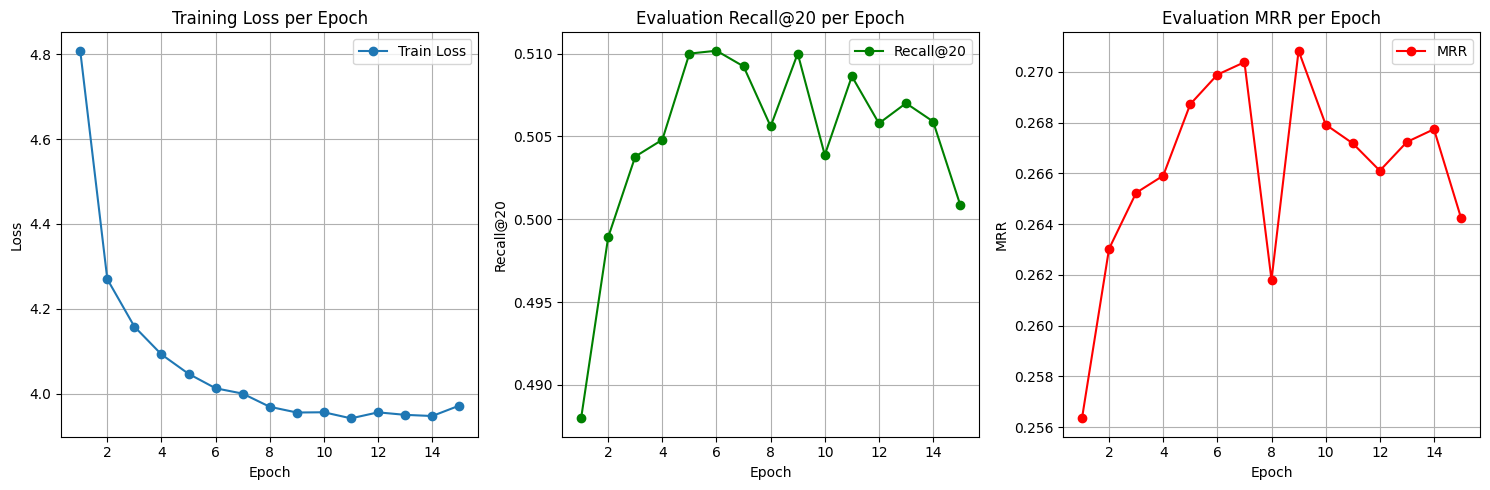

In [13]:
# 5. RUN GES-REC (UPDATED)

# Create directory to save models
MODEL_SAVE_PATH = "./gesrec_checkpoints"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print("\n--- Initializing GES-Rec Model ---")
ges_rec_model = GESRec(
    item_count=ITEM_COUNT,
    seq_dim=EMBEDDING_DIM,
    graph_dim=GRAPH_EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    graph_embeddings_tensor=GRAPH_EMBEDDINGS
)

criterion = nn.CrossEntropyLoss(ignore_index=0) 
optimizer = optim.Adam(ges_rec_model.parameters(), lr=OPTIMIZER_LEARNING_RATE)

# Start Training and get history
final_model, training_history = train_model(
    ges_rec_model, 
    train_loader, 
    test_loader, 
    optimizer, 
    criterion, 
    epochs=EPOCHS, 
    model_path=MODEL_SAVE_PATH
)

print("\n--- Execution Complete ---")

# --- Visualization ---
visualize_results(training_history, K_RECS)